In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
import random

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
class SpeechHMM:
    """Hidden Markov Model for Speech Phoneme Transitions"""
    
    def __init__(self):
        # Define phonemes (hidden states)
        self.phonemes = ['/s/', '/p/', '/ie:/', '/tS/']
        
        # Define observations (acoustic properties)
        self.observations = ['Energy', 'Pitch', 'Duration']
        
        # Initial probabilities (starting with /s/ has probability 1)
        self.initial_probs = {
            '/s/': 1.0,
            '/p/': 0.0,
            '/ie:/': 0.0,
            '/tS/': 0.0
        }
        
        # Transition probabilities (from document)
        self.transition_probs = {
            '/s/': {'/s/': 0.0, '/p/': 1.0, '/ie:/': 0.0, '/tS/': 0.0},
            '/p/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 1.0, '/tS/': 0.0},
            '/ie:/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 0.0, '/tS/': 1.0},
            '/tS/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 0.0, '/tS/': 1.0}
        }
        
        # Emission probabilities (from document)
        self.emission_probs = {
            '/s/': {'Energy': 0.7, 'Pitch': 0.2, 'Duration': 0.1},
            '/p/': {'Energy': 0.5, 'Pitch': 0.3, 'Duration': 0.2},
            '/ie:/': {'Energy': 0.3, 'Pitch': 0.5, 'Duration': 0.2},
            '/tS/': {'Energy': 0.4, 'Pitch': 0.4, 'Duration': 0.2}
        }
    
    def get_transition_matrix(self) -> pd.DataFrame:
        """Convert transition probabilities to DataFrame"""
        matrix = []
        for from_state in self.phonemes:
            row = [self.transition_probs[from_state][to_state] 
                   for to_state in self.phonemes]
            matrix.append(row)
        return pd.DataFrame(matrix, 
                          index=self.phonemes, 
                          columns=self.phonemes)
    
    def get_emission_matrix(self) -> pd.DataFrame:
        """Convert emission probabilities to DataFrame"""
        matrix = []
        for phoneme in self.phonemes:
            row = [self.emission_probs[phoneme][obs] 
                   for obs in self.observations]
            matrix.append(row)
        return pd.DataFrame(matrix, 
                          index=self.phonemes, 
                          columns=self.observations)
    
    def get_initial_probs_series(self) -> pd.Series:
        """Convert initial probabilities to Series"""
        return pd.Series(self.initial_probs)

# Initialize HMM
hmm = SpeechHMM()
print("HMM initialized successfully!")

HMM initialized successfully!


In [4]:
def display_hmm_parameters(hmm: SpeechHMM):
    """Display all HMM parameters in a neat format"""
    
    print("="*60)
    print("HIDDEN MARKOV MODEL FOR SPEECH PHONEME TRANSITIONS")
    print("="*60)
    
    print("\n1. INITIAL PROBABILITIES")
    print("-" * 40)
    initial_df = pd.DataFrame({
        'Phoneme': hmm.phonemes,
        'Initial Probability': [hmm.initial_probs[p] for p in hmm.phonemes]
    })
    print(initial_df.to_string(index=False))
    
    print("\n\n2. TRANSITION PROBABILITIES")
    print("-" * 40)
    print("(Probability of transitioning from row phoneme to column phoneme)\n")
    transition_matrix = hmm.get_transition_matrix()
    print(transition_matrix)
    
    print("\n\n3. EMISSION PROBABILITIES")
    print("-" * 40)
    print("(Probability of observing acoustic property given a phoneme)\n")
    emission_matrix = hmm.get_emission_matrix()
    print(emission_matrix)
    
    print("\n" + "="*60)

# Display parameters
display_hmm_parameters(hmm)

HIDDEN MARKOV MODEL FOR SPEECH PHONEME TRANSITIONS

1. INITIAL PROBABILITIES
----------------------------------------
Phoneme  Initial Probability
    /s/                  1.0
    /p/                  0.0
  /ie:/                  0.0
   /tS/                  0.0


2. TRANSITION PROBABILITIES
----------------------------------------
(Probability of transitioning from row phoneme to column phoneme)

       /s/  /p/  /ie:/  /tS/
/s/    0.0  1.0    0.0   0.0
/p/    0.0  0.0    1.0   0.0
/ie:/  0.0  0.0    0.0   1.0
/tS/   0.0  0.0    0.0   1.0


3. EMISSION PROBABILITIES
----------------------------------------
(Probability of observing acoustic property given a phoneme)

       Energy  Pitch  Duration
/s/       0.7    0.2       0.1
/p/       0.5    0.3       0.2
/ie:/     0.3    0.5       0.2
/tS/      0.4    0.4       0.2



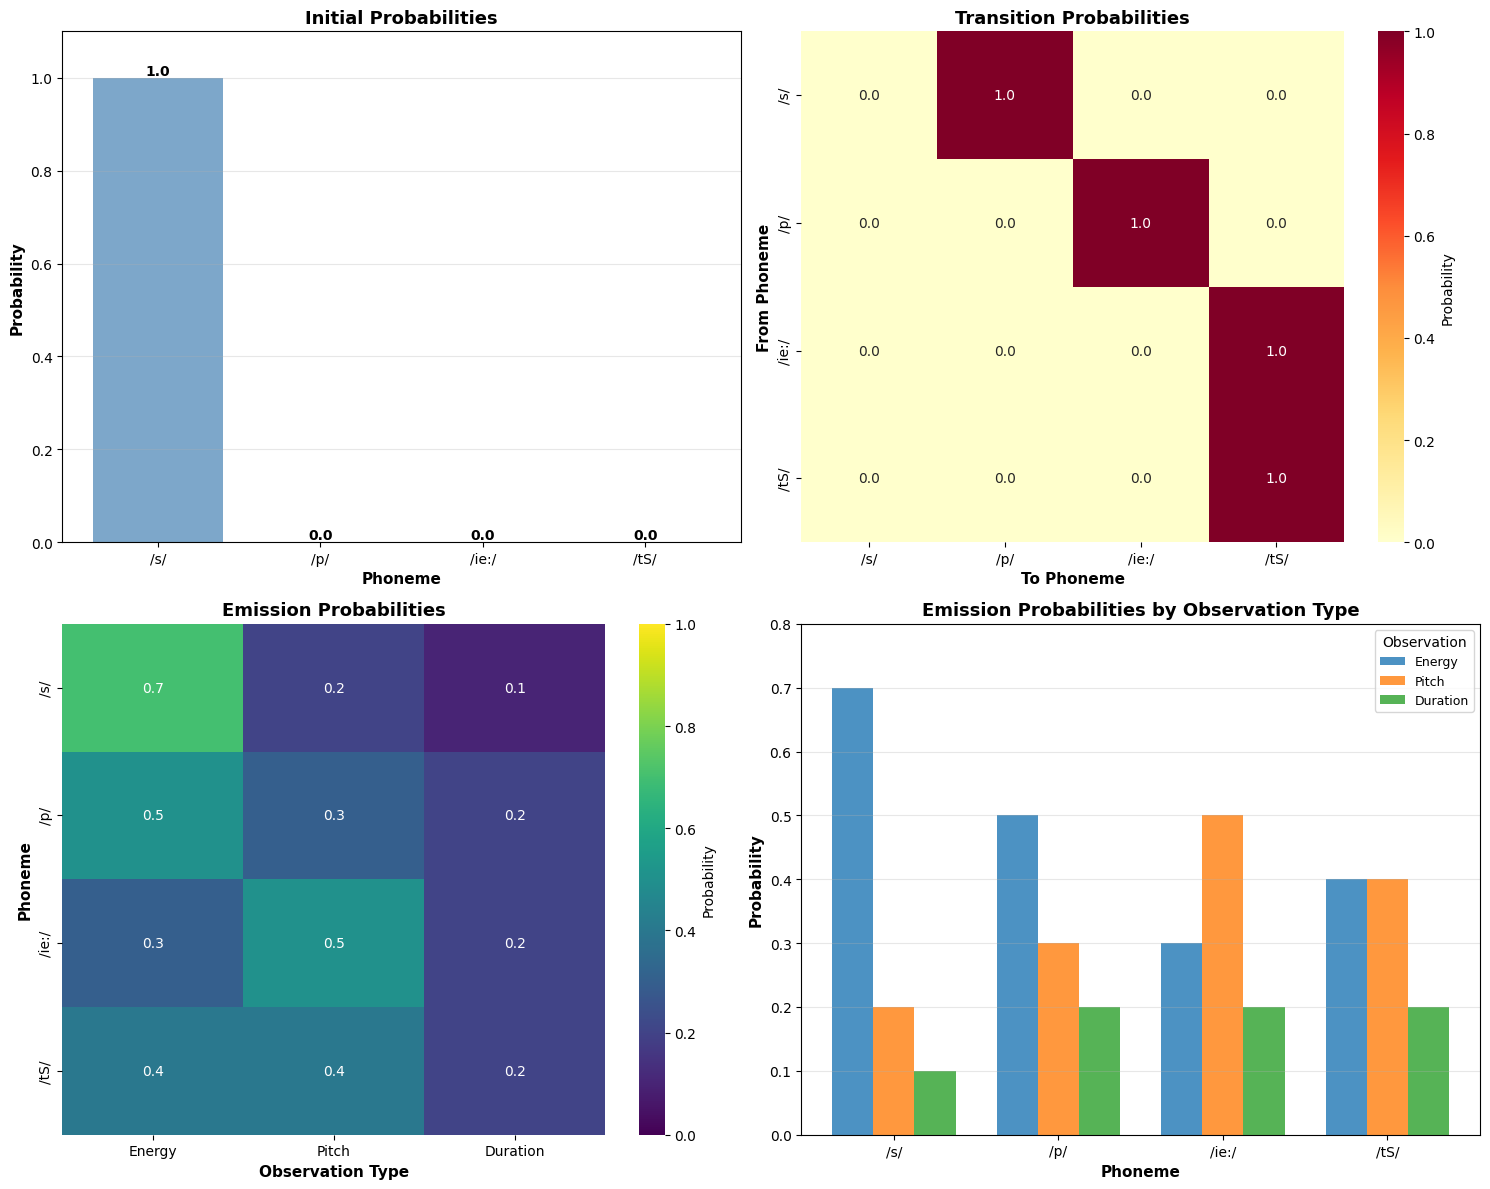

In [5]:
def visualize_hmm(hmm: SpeechHMM):
    """Create comprehensive visualizations of HMM parameters"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Initial Probabilities Bar Chart
    ax1 = axes[0, 0]
    initial_probs_list = [hmm.initial_probs[p] for p in hmm.phonemes]
    bars = ax1.bar(hmm.phonemes, initial_probs_list, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Phoneme', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Probability', fontsize=11, fontweight='bold')
    ax1.set_title('Initial Probabilities', fontsize=13, fontweight='bold')
    ax1.set_ylim([0, 1.1])
    ax1.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold')
    
    # 2. Transition Probability Heatmap
    ax2 = axes[0, 1]
    transition_matrix = hmm.get_transition_matrix()
    sns.heatmap(transition_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Probability'}, ax=ax2, vmin=0, vmax=1)
    ax2.set_xlabel('To Phoneme', fontsize=11, fontweight='bold')
    ax2.set_ylabel('From Phoneme', fontsize=11, fontweight='bold')
    ax2.set_title('Transition Probabilities', fontsize=13, fontweight='bold')
    
    # 3. Emission Probability Heatmap
    ax3 = axes[1, 0]
    emission_matrix = hmm.get_emission_matrix()
    sns.heatmap(emission_matrix, annot=True, fmt='.1f', cmap='viridis', 
                cbar_kws={'label': 'Probability'}, ax=ax3, vmin=0, vmax=1)
    ax3.set_xlabel('Observation Type', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Phoneme', fontsize=11, fontweight='bold')
    ax3.set_title('Emission Probabilities', fontsize=13, fontweight='bold')
    
    # 4. Emission Probabilities Grouped Bar Chart
    ax4 = axes[1, 1]
    x = np.arange(len(hmm.phonemes))
    width = 0.25
    
    for i, obs in enumerate(hmm.observations):
        values = [hmm.emission_probs[p][obs] for p in hmm.phonemes]
        ax4.bar(x + i*width, values, width, label=obs, alpha=0.8)
    
    ax4.set_xlabel('Phoneme', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Probability', fontsize=11, fontweight='bold')
    ax4.set_title('Emission Probabilities by Observation Type', 
                  fontsize=13, fontweight='bold')
    ax4.set_xticks(x + width)
    ax4.set_xticklabels(hmm.phonemes)
    ax4.legend(title='Observation', fontsize=9)
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim([0, 0.8])
    
    plt.tight_layout()
    plt.show()

# Generate visualizations
visualize_hmm(hmm)